In [57]:
import kagglehub

# Load the latest version
file_path = kagglehub.dataset_download(
  "dylanjcastillo/7k-books-with-metadata",
)

In [58]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(file_path,"books.csv"))
df.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


In [59]:
df_statistics = pd.DataFrame(columns=["Column", "Non-Null Count", "Null Count", "Data Type", "Unique Count"])
for col in df.columns:
    null_count = df[col].isna().sum()
    non_null_count = df.shape[0] - null_count
    data_type = df[col].dtypes
    unique_count = df[col].nunique()
    df_statistics.loc[len(df_statistics),:] = [col, non_null_count, null_count, data_type, unique_count]

df_statistics

,Column,Non-Null Count,Null Count,Data Type,Unique Count
0,isbn13,6810,0,int64,6810
1,isbn10,6810,0,str,6810
2,title,6810,0,str,6398
3,subtitle,2381,4429,str,2009
4,authors,6738,72,str,3780
5,categories,6711,99,str,567
6,thumbnail,6481,329,str,6481
7,description,6548,262,str,6474
8,published_year,6804,6,float64,94
9,average_rating,6767,43,float64,200


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

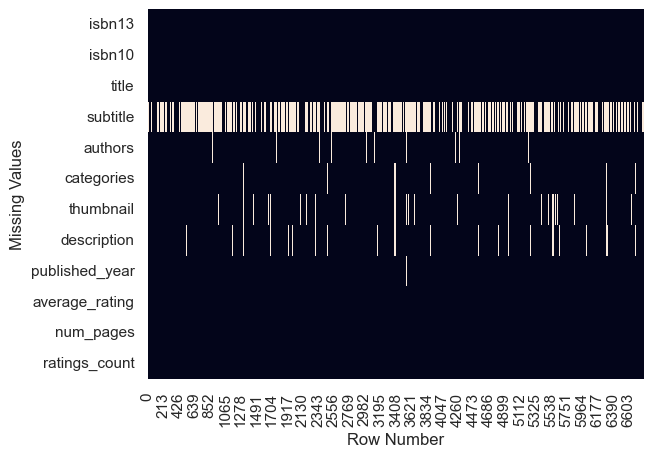

In [61]:
ax = plt.axes()
sns.heatmap(df.isna().transpose(), cbar=False, ax=ax)
plt.xlabel("Row Number")
plt.ylabel("Missing Values")
plt.show()

In [62]:
import numpy as np

df["missing_description"] = np.where(df["description"].isna(), 1, 0)
df["age_of_book"] = 2026 - df["published_year"]

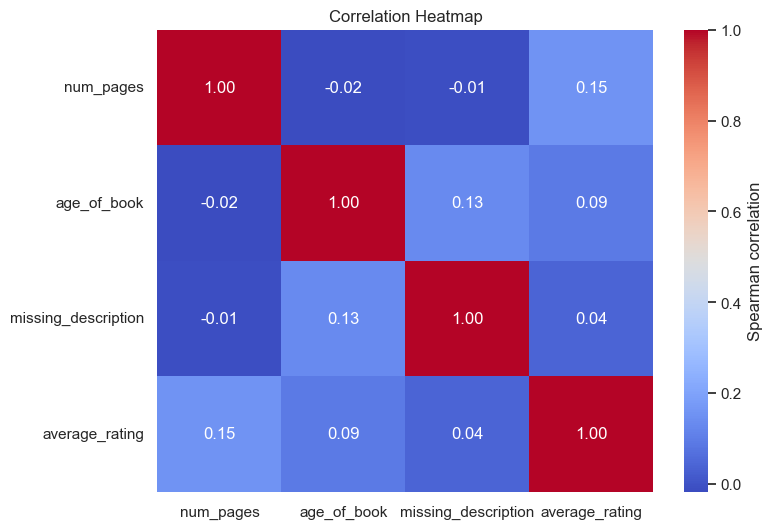

In [63]:
columns_of_interest = ["num_pages", "age_of_book", "missing_description", "average_rating"]
correlation_matrix = df[columns_of_interest].corr(method="spearman")

sns.set_theme(style="white")
plt.figure(figsize=(8,6))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                      cbar_kws={"label": "Spearman correlation"})
heatmap.set_title("Correlation Heatmap")
plt.show()

In [64]:
books_no_missing = df[ ~df["num_pages"].isna() & 
   ~df["description"].isna() & 
   ~df["published_year"].isna() & 
   ~df["average_rating"].isna()]

In [65]:
books_no_missing["categories"].value_counts().reset_index().sort_values("count", ascending=False)

,categories,count
0,Fiction,2523
1,Juvenile Fiction,534
2,Biography & Autobiography,391
3,History,258
4,Literary Criticism,164
...,...,...
526,Meditation,1
527,Gay men,1
528,Christian fiction,1
529,"Napoleonic Wars, 1800-1815",1


In [66]:
books_no_missing["words_in_description"] = books_no_missing["description"].str.split().str.len()

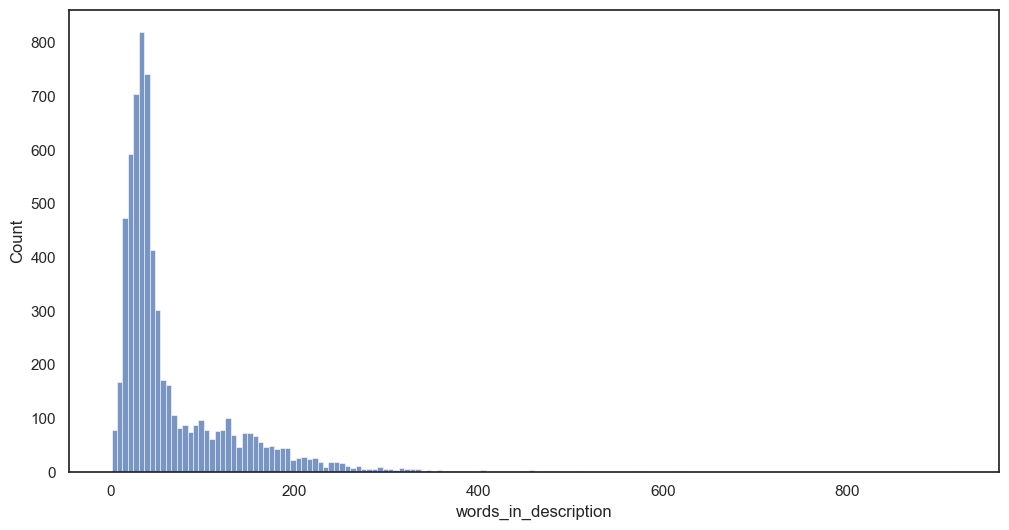

In [67]:
plt.figure(figsize=(12,6))
sns.histplot(books_no_missing, x="words_in_description")
plt.show()

In [68]:
books_no_missing.loc[books_no_missing["words_in_description"].between(1,4), "description"]

6                                           Donation.
11                                     Fantasy-roman.
748              Includes bibliographical references.
770                             Bound For Oregon (PB)
775                                No Marketing Blurb
812                                No Marketing Blurb
857                          First published in 1813.
944                         Edited by Maurice Hindle.
953                        DEFOE/ROBINSON CRUSOE (BC)
954                             Edited by John Carey.
962                         ALLEN/GETTING THINGS DONE
1054                            GILBERT/EAT PRAY LOVE
1056    "Graham Greene centennial, 1904-2004"--Cover.
1060                   STEINBECK/GRAPES OF WRATH (BC)
1346                                   Fantasy-roman.
1546                                      Winter 2003
1610                                      Winter 1999
1813                             National bestseller.
1981                        

In [69]:
books_no_missing.loc[books_no_missing["words_in_description"].between(5,14), "description"]

2       Volume Two of Stephen Donaldson's acclaimed se...
38      Koko is Peter Straub's foray into the psycholo...
70      A matter of life and death - and the Throne of...
77                         Nonsense rhyming story. 4 yrs+
84      A study guide for the novel There's a Boy in t...
                              ...                        
6715    The first comprehensive guide to addressing Na...
6726       Presents two complete novels from Henry James.
6757                          Audio Book- unabriged on CD
6776    Raymond Chandler meets The Exorcist. Classic n...
6795    Book Of Five Rings is a Kodansha International...
Name: description, Length: 308, dtype: str

In [70]:
books_no_missing.loc[books_no_missing["words_in_description"].between(15,24), "description"]

10      One of Sidney Sheldon's most popular and bests...
32      Tells the story of three generations of Chines...
36      A magical and fantastic collection of early st...
57      A young drifter finds more than he bargained f...
68      A new 'The Doors of Perception' for the 21st c...
                              ...                        
6767    Everything from the fingerprints of the gods t...
6782    Displays one of America's leading physicist's ...
6783    Basics Illustration 01: Thinking Visually expl...
6789    Provides an introduction to the American artis...
6809    This is a jubilant and rewarding collection of...
Name: description, Length: 947, dtype: str

In [71]:
books_no_missing_25_words = books_no_missing[books_no_missing["words_in_description"]>=25]

In [75]:
books_no_missing_25_words["title_and_subtitle"] = (
    books_no_missing_25_words["title"] +
    np.where(
        books_no_missing_25_words["subtitle"].notna(),
        ": " + books_no_missing_25_words["subtitle"].astype(str),
        ""
    )
)

In [76]:
books_no_missing_25_words["title_and_subtitle"]

0                                                  Gilead
1                                   Spider's Web: A Novel
3                                          Rage of angels
4                                          The Four Loves
5                                     The Problem of Pain
                              ...                        
6802                                    Mistaken Identity
6803                                  Journey to the East
6804    The Monk Who Sold His Ferrari: A Fable About F...
6805       I Am that: Talks with Sri Nisargadatta Maharaj
6808                             The Berlin Phenomenology
Name: title_and_subtitle, Length: 5197, dtype: str

In [77]:
books_no_missing_25_words["tagged_description"] = books_no_missing_25_words[["isbn13", "description"]].astype(str).agg(" ".join, axis=1)

In [78]:
books_no_missing_25_words["tagged_description"]

0       9780002005883 A NOVEL THAT READERS and critics...
1       9780002261982 A new 'Christie for Christmas' -...
3       9780006178736 A memorable, mesmerizing heroine...
4       9780006280897 Lewis' work on the nature of lov...
5       9780006280934 "In The Problem of Pain, C.S. Le...
                              ...                        
6802    9788172235222 On A Train Journey Home To North...
6803    9788173031014 This book tells the tale of a ma...
6804    9788179921623 Wisdom to Create a Life of Passi...
6805    9788185300535 This collection of the timeless ...
6808    9789027712059 Since the three volume edition o...
Name: tagged_description, Length: 5197, dtype: str

In [81]:
books_no_missing_25_words = books_no_missing_25_words.drop(
    columns=["subtitle", "missing_description", "age_of_book", "words_in_description"],
)

In [82]:
books_no_missing_25_words.to_csv("./books-data/books-cleaned.csv", index=False)